In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(scater)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multicore", workers = 8)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


## Li et al. 2023. - https://doi.org/10.1016/j.cell.2023.11.016

In [2]:
load('/projects/0/einf2548/cruiz/dmg/data/references/Li2023/OMIX005437-01.RData')
load('/projects/0/einf2548/cruiz/dmg/data/references/Li2023/OMIX005437-02.RData')

In [3]:
reference <- merge(astro_scrna_obj, c(cere_rg,cor_rg,cs_neural_tube,dien_rg,mid_rg,
                                      npc_scrna_obj,opc_scrna_obj,sub_obj_gluta_1_4),
                  merge.data=FALSE)
reference

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


An object of class Seurat 
36601 features across 74538 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data

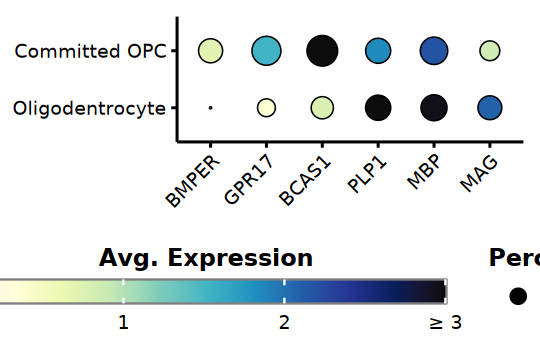

In [24]:
options(repr.plot.height = 3, repr.plot.width = 4.5)

Idents(reference) <- reference$celltype
genes <- c('BMPER', 'GPR17','BCAS1',
           'PLP1', 'MBP', 'MAG')
p1 <- SCpubr::do_DotPlot(sample = subset(reference, idents=c('Committed OPC','Oligodentrocyte')),max.cutoff = 3, 
                        features = genes)
p1

In [14]:
braun <- readRDS('/projects/0/einf2548/cruiz/dmg/data/references/Braun2023/cop_fetal_oligo_adult.rds')
braun

An object of class Seurat 
4702 features across 27379 samples within 1 assay 
Active assay: RNA (4702 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

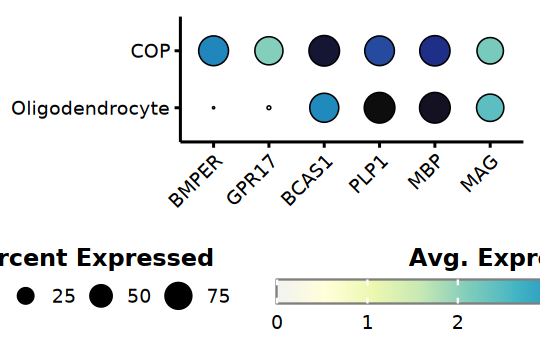

In [25]:
options(repr.plot.height = 3, repr.plot.width = 4.5)

genes <- c('BMPER', 'GPR17','BCAS1',
           'PLP1', 'MBP', 'MAG')
p2 <- SCpubr::do_DotPlot(sample = subset(braun, idents=c('COP','Oligodendrocyte')), 
                        features = genes)
p2

In [19]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds')
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

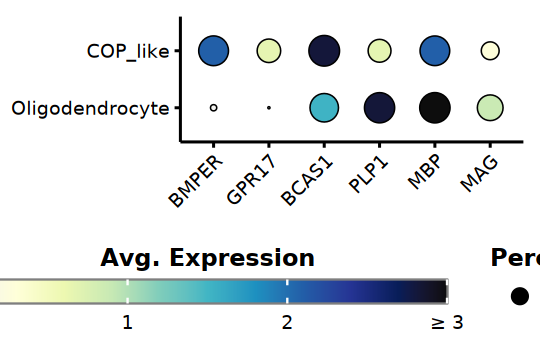

In [27]:
options(repr.plot.height = 3, repr.plot.width = 4.5)

Idents(dmg) <- dmg$deconv
genes <- c('BMPER', 'GPR17','BCAS1',
           'PLP1', 'MBP', 'MAG')
p3 <- SCpubr::do_DotPlot(sample = subset(dmg, idents=c('COP_like','Oligodendrocyte')),max.cutoff = 3, 
                        features = genes)
p3

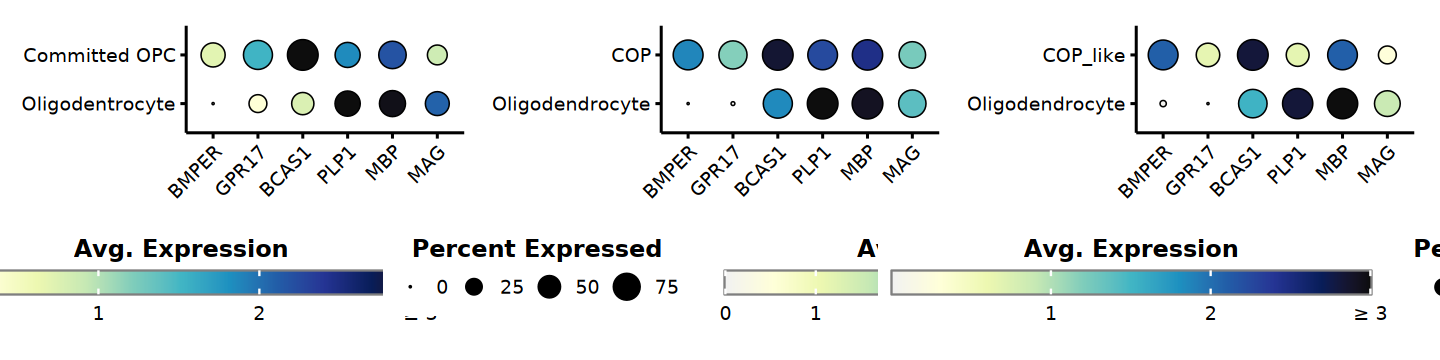

In [28]:
options(repr.plot.height = 3, repr.plot.width = 12)

p1 | p2 | p3

In [29]:
ggsave('figures/cop_vs_oligodendrocyte_references_and_atlas.pdf', height = 3, width = 12)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 3' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x